<a href="https://colab.research.google.com/github/baldiea75-tech/carisurg-portfolio/blob/feat%2Fweek-6-refactor/Week6_Baseline_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
Libraries imported.
pandas 2.2.2 | numpy 2.0.2
Dataset loaded: 55,121 encounters x 225 columns
Target column: esi
Leakage columns excluded: ['disposition', 'previousdispo']
Model will use 208 features to predict esi
X shape: (55121, 208)
y shape: (55121,)
Random seed used: 42
Training patients: 44,096
Testing patients: 11,025
ESI 1 patients in training set: 61
ESI 1 patients in test set: 16
Dummy baseline accuracy: 0.3754
Logistic regression accuracy: 0.6668
Decision tree accuracy: 0.5559


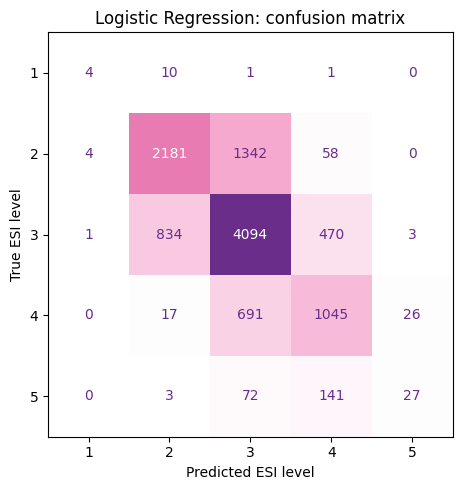

Saved: w6_confusion_logreg.png


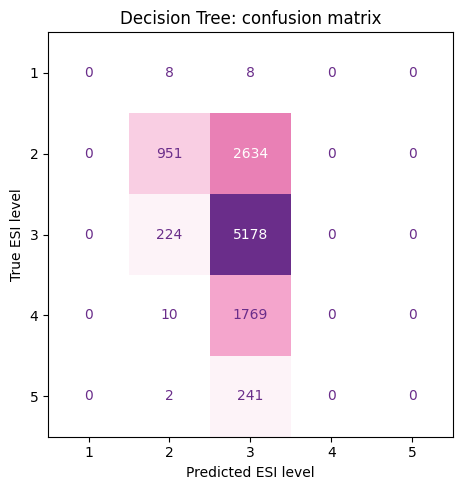

Saved: w6_confusion_tree.png
=== Logistic Regression: per class precision, recall, F1 ===
              precision    recall  f1-score   support

           1      0.444     0.250     0.320        16
           2      0.716     0.608     0.658      3585
           3      0.660     0.758     0.706      5402
           4      0.609     0.587     0.598      1779
           5      0.482     0.111     0.181       243

    accuracy                          0.667     11025
   macro avg      0.582     0.463     0.492     11025
weighted avg      0.666     0.667     0.661     11025

=== Decision Tree: per class precision, recall, F1 ===
              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.796     0.265     0.398      3585
           3      0.527     0.959     0.680      5402
           4      0.000     0.000     0.000      1779
           5      0.000     0.000     0.000       243

    accuracy                          0.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


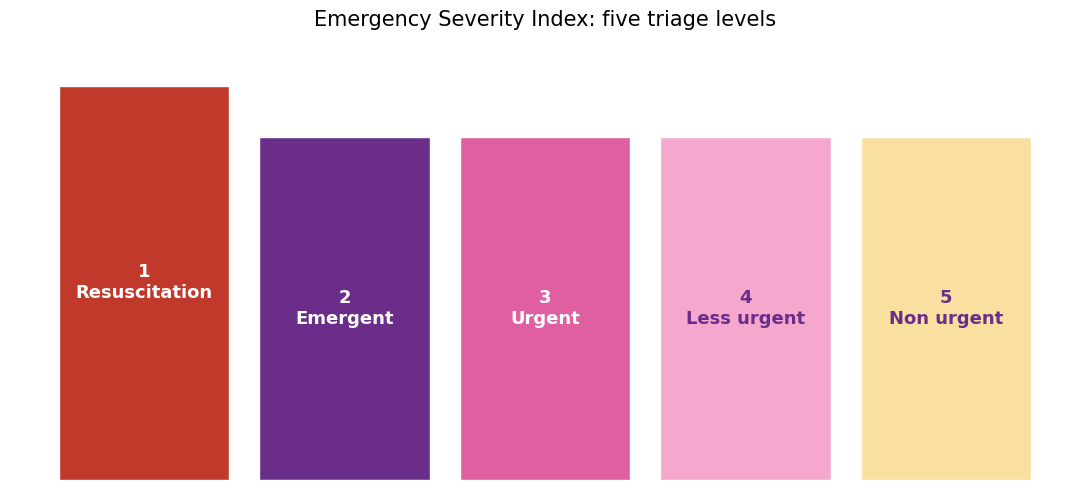

Saved: video_graphic_1_esi_levels.png


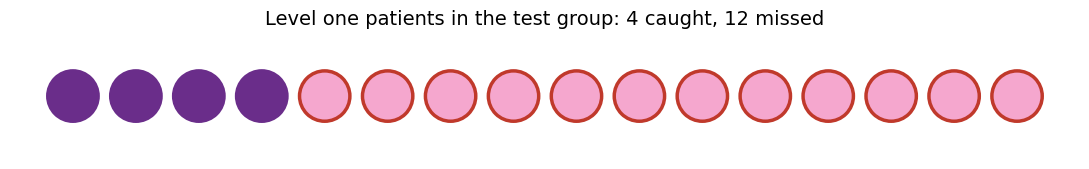

Saved: video_graphic_2_caught_vs_missed.png


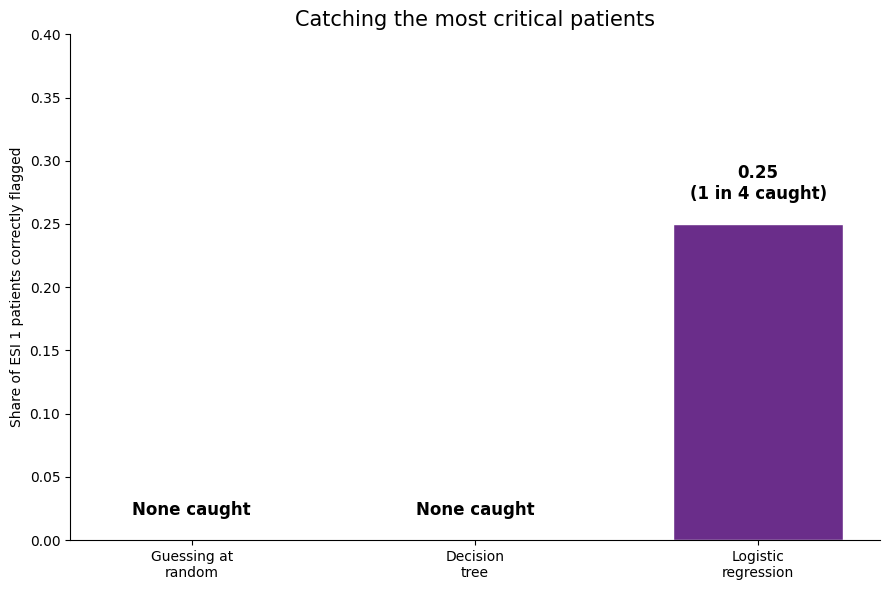

Saved: video_graphic_3_model_comparison.png


In [1]:
# CariSurg MedTech Pathways - Week 6 Baseline Models
# Week 6: Logistic Regression and Decision Tree for ESI Triage Classification
# Author: Ashi Baldie
# Dataset: Yale EMMLC Admission Prediction Triage
#          (yaleemmlc_admissionprediction_triage.csv)


# CELL 1 - SETUP: Mount Drive and import libraries
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, f1_score, recall_score, ConfusionMatrixDisplay

drive.mount('/content/drive')

# Colour palette: yellow, pink, purple, red as accent
YELLOW  = '#F4B942'
PINK    = '#E05FA0'
PURPLE  = '#6A2D8A'
RED     = '#C0392B'
LIGHT_PURPLE = '#C9A6E0'
LIGHT_PINK   = '#F5A7CE'
LIGHT_YELLOW = '#FAE0A0'
cm_cmap = LinearSegmentedColormap.from_list('cm_cmap', ['#FFFFFF', LIGHT_PINK, PINK, PURPLE])

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

print('Libraries imported.')
print(f'pandas {pd.__version__} | numpy {np.__version__}')


# CELL 2 - LOAD DATA
DATA_PATH = '/content/drive/MyDrive/carisurg-portfolio/yaleemmlc_admissionprediction_triage.csv'
df = pd.read_csv(DATA_PATH, index_col=0)

print(f'Dataset loaded: {df.shape[0]:,} encounters x {df.shape[1]} columns')


# CELL 3 - DEFINE COLUMN FAMILIES
TARGET = 'esi'   # Emergency Severity Index: 1 (most urgent) to 5 (least)

VITALS = [
    'triage_vital_hr',    # Heart rate
    'triage_vital_sbp',   # Systolic blood pressure
    'triage_vital_dbp',   # Diastolic blood pressure
    'triage_vital_rr',    # Respiratory rate
    'triage_vital_o2',    # Oxygen saturation
    'triage_vital_temp',  # Temperature
    'triage_glucose',     # Blood glucose
]

DEMOGRAPHICS = ['age', 'gender', 'ethnicity', 'race', 'lang', 'religion',
                'maritalstatus', 'employstatus', 'insurance_status']

ADMIN = ['dep_name', 'arrivalmode', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin']

# Known only after the visit ends. Excluded so the model never trains on the answer.
LEAKAGE = ['disposition', 'previousdispo']

# Features = everything except the target, leakage, admin and demographic columns.
# This baseline is judged purely on vitals and presenting complaints, the clues
# available the moment a nurse first sees the patient.
FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

print(f'Target column: {TARGET}')
print(f'Leakage columns excluded: {LEAKAGE}')
print(f'Model will use {len(FEATURES)} features to predict {TARGET}')


# CELL 4 - DEFINE X AND y
# esi loads as float64 in the raw file. Cast to int so confusion matrix
# labels read 1 to 5, not 1.0 to 5.0.
X = df[FEATURES]
y = df[TARGET].astype(int)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')


# CELL 5 - TRAIN TEST SPLIT
# 80/20 split, stratified on esi so both sets keep the same triage mix.
# Fixed random seed of 42 used throughout this notebook so the split
# is reproducible by anyone re-running it.
RANDOM_SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

print(f'Random seed used: {RANDOM_SEED}')
print(f'Training patients: {X_train.shape[0]:,}')
print(f'Testing patients: {X_test.shape[0]:,}')
print(f'ESI 1 patients in training set: {(y_train == 1).sum()}')
print(f'ESI 1 patients in test set: {(y_test == 1).sum()}')


# CELL 6 - DUMMY BASELINE
# Predicts at random but respects the same class balance as training data.
# This is the floor any real model must beat.
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_SEED)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

print(f'Dummy baseline accuracy: {dummy.score(X_test, y_test):.4f}')


# CELL 7 - LOGISTIC REGRESSION
# Scaler fit on training data only, to avoid leaking test set statistics.
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
logreg.fit(X_train_s, y_train)
pred_logreg = logreg.predict(X_test_s)

print(f'Logistic regression accuracy: {logreg.score(X_test_s, y_test):.4f}')


# CELL 8 - DECISION TREE
# max_depth is capped at 5, not left at the default of None. A shallow tree
# can be drawn as a short flowchart and explained to a clinician in one
# sitting, at some cost to raw accuracy. An unbounded tree would likely
# score higher on paper while becoming unexplainable and prone to
# memorising the training data rather than learning general patterns.
tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_SEED)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

print(f'Decision tree accuracy: {tree.score(X_test, y_test):.4f}')


# CELL 9 - CONFUSION MATRIX: LOGISTIC REGRESSION
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_logreg, ax=ax, colorbar=False, cmap=cm_cmap,
    display_labels=[1, 2, 3, 4, 5]
)
ax.set_xlabel('Predicted ESI level')
ax.set_ylabel('True ESI level')
ax.set_title('Logistic Regression: confusion matrix')
plt.tight_layout()
plt.savefig('w6_confusion_logreg.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: w6_confusion_logreg.png')


# CELL 10 - CONFUSION MATRIX: DECISION TREE
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_tree, ax=ax, colorbar=False, cmap=cm_cmap,
    display_labels=[1, 2, 3, 4, 5]
)
ax.set_xlabel('Predicted ESI level')
ax.set_ylabel('True ESI level')
ax.set_title('Decision Tree: confusion matrix')
plt.tight_layout()
plt.savefig('w6_confusion_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: w6_confusion_tree.png')


# CELL 11 - PER CLASS METRICS
# Accuracy, precision, recall and F1 broken down per ESI level for both
# models, not just as a single aggregate score.
print('=== Logistic Regression: per class precision, recall, F1 ===')
print(classification_report(y_test, pred_logreg, digits=3))

print('=== Decision Tree: per class precision, recall, F1 ===')
print(classification_report(y_test, pred_tree, digits=3))


# CELL 12 - MACRO F1 VS WEIGHTED F1
# Macro F1 treats every ESI level as equally important. Weighted F1 gives
# more credit for the large classes, ESI 2 and ESI 3, so the two numbers
# pull apart whenever a model is imbalanced in how well it does across
# classes, exactly as the decision tree is below.
print('=== Macro F1 vs weighted F1 ===')
for name, preds in [('Dummy', pred_dummy), ('Logistic Regression', pred_logreg), ('Decision Tree', pred_tree)]:
    macro = f1_score(y_test, preds, average='macro')
    weighted = f1_score(y_test, preds, average='weighted')
    print(f'{name:22s} macro F1 = {macro:.3f}   weighted F1 = {weighted:.3f}')

print('Macro F1 treats every ESI level as equally important. Weighted F1 gives')
print('more credit for the large classes, ESI 2 and ESI 3. A model can score')
print('well on weighted F1 while quietly failing ESI 1.')


# CELL 13 - RECALL FOR ESI 1
# This is the primary metric for this baseline. Of the patients who truly
# needed resuscitation, how many did the model actually catch.
print('=== Recall for ESI 1: the number that matters most ===')
for name, preds in [('Dummy', pred_dummy), ('Logistic Regression', pred_logreg), ('Decision Tree', pred_tree)]:
    r = recall_score(y_test, preds, labels=[1], average=None)[0]
    n_esi1 = (y_test == 1).sum()
    caught = round(r * n_esi1)
    print(f'{name:22s} recall = {r:.3f}   ({caught} of {n_esi1} ESI 1 patients caught)')


# CELL 14 - MODEL COMPARISON TABLE
def summarise(name, preds):
    return {
        'model': name,
        'accuracy': round((preds == y_test).mean(), 3),
        'macro_F1': round(f1_score(y_test, preds, average='macro'), 3),
        'weighted_F1': round(f1_score(y_test, preds, average='weighted'), 3),
        'recall_ESI1': round(recall_score(y_test, preds, labels=[1], average=None)[0], 3),
    }

table = pd.DataFrame([
    summarise('Dummy (baseline)', pred_dummy),
    summarise('Logistic Regression', pred_logreg),
    summarise('Decision Tree', pred_tree),
])
print('=== Model comparison ===')
print(table.to_string(index=False))


# CELL 15 - REPRODUCIBILITY SUMMARY
print('=== Reproducibility ===')
print(f'Random seed: {RANDOM_SEED} (train test split, logistic regression, decision tree)')
print('Train test split: 80 percent train, 20 percent test, stratified on esi')
print('Decision tree max_depth: 5, chosen for explainability over raw accuracy')
print('Confusion matrices saved: w6_confusion_logreg.png, w6_confusion_tree.png')


# CELL 16 - VIDEO GRAPHIC 1: ESI LEVELS WITH LEVEL 1 HIGHLIGHTED
# A plain visual of the five triage levels for use in the clinical explainer video.
ESI_LABELS = ['Resuscitation', 'Emergent', 'Urgent', 'Less urgent', 'Non urgent']
esi_colors = [RED, PURPLE, PINK, LIGHT_PINK, LIGHT_YELLOW]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(1, 6), [1, 1, 1, 1, 1], color=esi_colors, edgecolor='white', width=0.85)
bars[0].set_height(1.15)
for i, (bar, label) in enumerate(zip(bars, ESI_LABELS)):
    text_color = 'white' if i < 3 else PURPLE
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, f'{i+1}\n{label}',
            ha='center', va='center', fontsize=13, fontweight='bold', color=text_color)
ax.set_ylim(0, 1.3)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title('Emergency Severity Index: five triage levels', fontsize=15)
plt.tight_layout()
plt.savefig('video_graphic_1_esi_levels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: video_graphic_1_esi_levels.png')


# CELL 17 - VIDEO GRAPHIC 2: CAUGHT VERSUS MISSED FOR ESI 1
# Shows, patient by patient, how many of the true ESI 1 test cases the
# logistic regression model actually caught.
n_esi1 = int((y_test == 1).sum())
n_caught = int(((y_test == 1) & (pred_logreg == 1)).sum())
n_missed = n_esi1 - n_caught

fig, ax = plt.subplots(figsize=(11, 4))
positions = np.arange(n_esi1)
colors_dots = [PURPLE] * n_caught + [LIGHT_PINK] * n_missed
edge_colors = [PURPLE] * n_caught + [RED] * n_missed
for i, (x, c, e) in enumerate(zip(positions, colors_dots, edge_colors)):
    circle = plt.Circle((x, 0), 0.4, color=c, ec=e, linewidth=2.5)
    ax.add_patch(circle)
ax.set_xlim(-1, n_esi1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'Level one patients in the test group: {n_caught} caught, {n_missed} missed', fontsize=14)
plt.tight_layout()
plt.savefig('video_graphic_2_caught_vs_missed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: video_graphic_2_caught_vs_missed.png')


# CELL 18 - VIDEO GRAPHIC 3: MODEL COMPARISON ON ESI 1 RECALL
# The same recall figures from Cell 13, shown as a simple bar chart for the video.
model_names = ['Guessing at\nrandom', 'Decision\ntree', 'Logistic\nregression']
recalls = [
    recall_score(y_test, pred_dummy, labels=[1], average=None)[0],
    recall_score(y_test, pred_tree, labels=[1], average=None)[0],
    recall_score(y_test, pred_logreg, labels=[1], average=None)[0],
]
bar_colors = [LIGHT_YELLOW, PINK, PURPLE]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(model_names, recalls, color=bar_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, recalls):
    label = 'None caught' if val == 0 else f'{val:.2f}\n(1 in 4 caught)'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, label,
            ha='center', fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.4)
ax.set_ylabel('Share of ESI 1 patients correctly flagged')
ax.set_title('Catching the most critical patients', fontsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('video_graphic_3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: video_graphic_3_model_comparison.png')
